# Loading Necessary library

In [135]:
# #installing packages
# !pip install category-encoders
# !pip install -U scikit-learn
#!pip install scipy

In [136]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import category_encoders as ce
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import math 
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string
from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
import datetime
from collections import Counter
from IPython.display import clear_output
from sklearn import datasets, linear_model
from sklearn.model_selection import LeaveOneOut
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import mutual_info_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score, explained_variance_score, make_scorer,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import LeaveOneOut, cross_val_score,KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

# Loading the Data

In [137]:
df=pd.read_csv("Tetuan City power consumption.csv")

## Finding the shape and information of the table. 

In [138]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [140]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
Wind Speed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
general diffuse flows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
diffuse flows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
Zone 1 Power Consumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone 2 Power Consumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone 3 Power Consumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


In [141]:
df.shape
print ("There are {} number of rows and {} number of columns in the dataset".format (df.shape[0],df.shape[1]))

There are 52416 number of rows and 9 number of columns in the dataset


# Data Preprocessing

## Date Feature Extraction and Resampling 

In [142]:
# convert the date column into a datetime object
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [143]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

In [144]:
df['Aggregated Consumption']=df['Zone 1 Power Consumption']+df['Zone 1 Power Consumption']+df['Zone 1 Power Consumption']

In [145]:
df_Hourly=df.resample('1H', on='DateTime').aggregate({'DateTime':'mean', 'Temperature':'mean', 'Humidity':'mean', 'Wind Speed':'mean',
       'general diffuse flows':'mean', 'diffuse flows':'mean', 'Zone 1 Power Consumption':'sum',
       'Zone 2  Power Consumption':'sum', 'Zone 3  Power Consumption':'sum','Aggregated Consumption':'sum'})

In [146]:
df_Hourly.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption'],
      dtype='object')

In [147]:
# convert the date column into a datetime object
# df['DateTime'] = pd.to_datetime(df['DateTime'])
# extract the day, month, and year components
df['day'] = df['DateTime'].dt.day
df['Day of Week'] = df['DateTime'].dt.day_of_week
df['Day of Year'] = df['DateTime'].dt.day_of_year
df['hour'] = df['DateTime'].dt.hour
df['minute'] = df['DateTime'].dt.minute
df['month'] = df['DateTime'].dt.month
df['quarter'] = df['DateTime'].dt.quarter
df['week'] = df['DateTime'].dt.isocalendar().week.astype('int64')

In [148]:
# convert the date column into a datetime object
# df_Hourly['DateTime'] = pd.to_datetime(df_Hourly['DateTime'])
# extract the day, month, and year components
df_Hourly['day'] = df_Hourly['DateTime'].dt.day
df_Hourly['Day of Week'] = df_Hourly['DateTime'].dt.day_of_week
df_Hourly['Day of Year'] = df_Hourly['DateTime'].dt.day_of_year
df_Hourly['hour'] = df_Hourly['DateTime'].dt.hour
df_Hourly['month'] = df_Hourly['DateTime'].dt.month
df_Hourly['quarter'] = df_Hourly['DateTime'].dt.quarter
df_Hourly['week'] = df_Hourly['DateTime'].dt.isocalendar().week.astype('int64')

In [149]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,minute,month,quarter,week
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,102167.08860,1,6,1,0,0,1,1,52
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,89444.05062,1,6,1,0,10,1,1,52
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,87384.30381,1,6,1,0,20,1,1,52
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,84686.58228,1,6,1,0,30,1,1,52
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,82007.08860,1,6,1,0,40,1,1,52


In [150]:
df_Hourly.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,month,quarter,week
DateTime,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,2017-01-01 00:25:00,6.196833,75.066667,0.081833,0.063500,0.098833,175187.84810,108160.48632,115512.28916,525563.54430,1,6,1,0,1,1,52
2017-01-01 01:00:00,2017-01-01 01:25:00,5.548833,77.583333,0.082000,0.056833,0.112500,147943.29114,96470.51672,102257.34940,443829.87342,1,6,1,1,1,1,52
2017-01-01 02:00:00,2017-01-01 02:25:00,5.054333,78.933333,0.082333,0.063000,0.129167,132498.22784,85984.19453,94056.86747,397494.68352,1,6,1,2,1,1,52
2017-01-01 03:00:00,2017-01-01 03:25:00,5.004333,77.083333,0.082833,0.059833,0.141000,124866.83544,79316.71732,89303.13253,374600.50632,1,6,1,3,1,1,52
2017-01-01 04:00:00,2017-01-01 04:25:00,5.097667,74.050000,0.082333,0.058000,0.122833,122855.69620,77529.48328,85902.65060,368567.08860,1,6,1,4,1,1,52


In [151]:
target1='Zone 1 Power Consumption'
target2='Zone 2  Power Consumption'
target3='Zone 3  Power Consumption'
target4='Aggregated Consumption'

## Null and Duplicate Value finding. 

In [152]:
df.isnull().any().any()

False

In [153]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
df.loc[df.duplicated(keep=False), :]

Number of duplicate rows = 0


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,minute,month,quarter,week


In [154]:
collist=df.columns

In [155]:
cat=[]
num=[]
for i in collist:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

[]
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute', 'month', 'quarter', 'week']


### Null Value Handling

##### Finding Null values in the data.


In [156]:
df.isnull().sum()
print("there are arond {} missing values in the dataset. ".format(df.isnull().sum().sum()))

there are arond 0 missing values in the dataset. 


## Outlier Handling

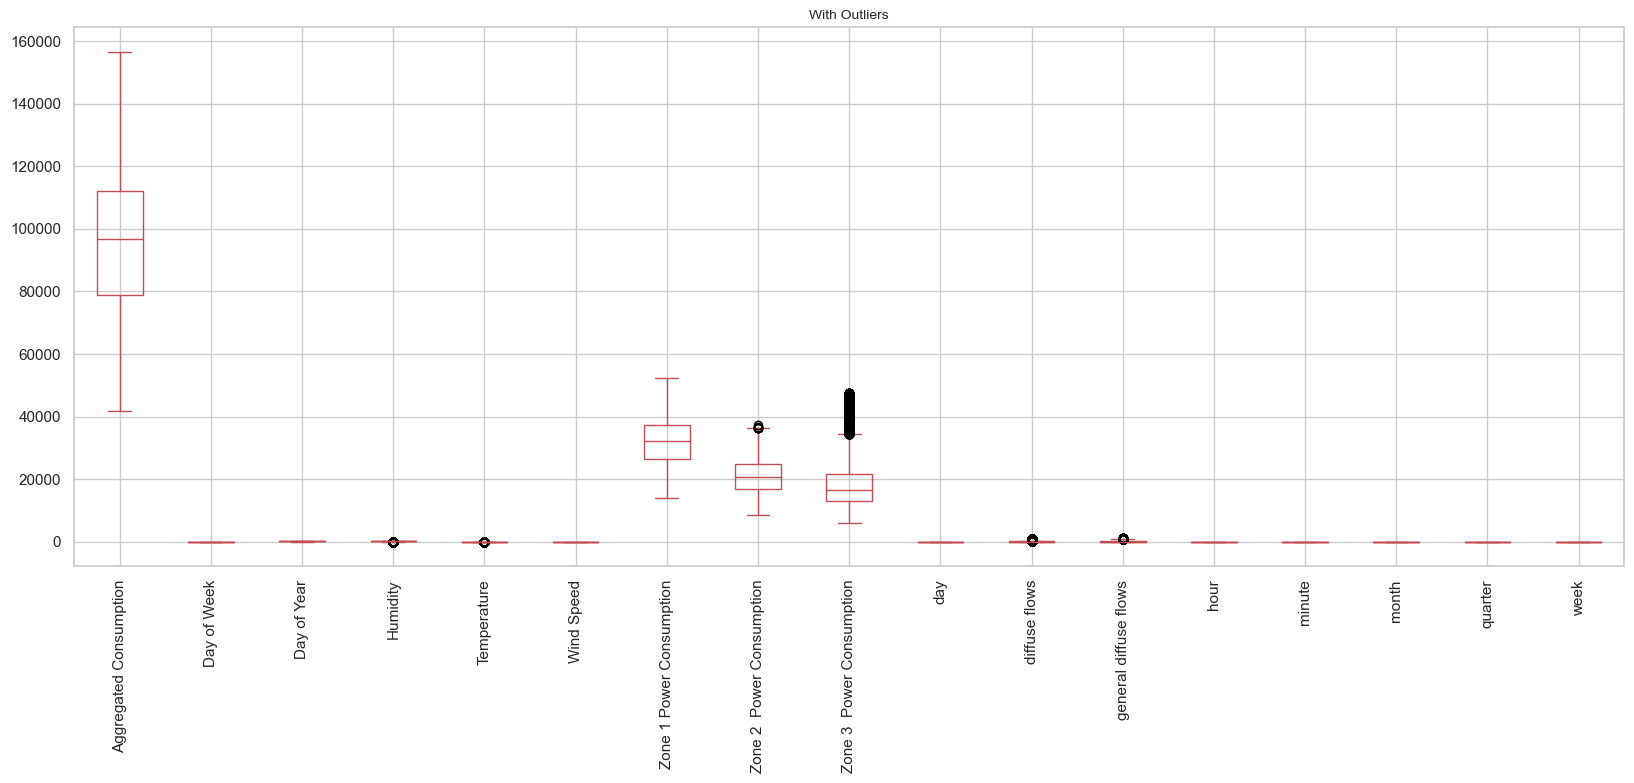

In [157]:
df[df.columns.difference(['Y house price of unit area'])].boxplot(figsize=(20,7),color='r',)
plt.xticks(rotation=90)
plt.title('With Outliers',fontsize=10)
plt.show()

##### Finding Outlier

In [158]:
def olf(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  ol=((df[column] < LB) | (df[column] > UB)).sum() 
  return print("Number of outliers in the column- {} is : {}".format(column,ol))

In [159]:
for i in num:
    olf(i)

Number of outliers in the column- DateTime is : 0
Number of outliers in the column- Temperature is : 142
Number of outliers in the column- Humidity is : 291
Number of outliers in the column- Wind Speed is : 0
Number of outliers in the column- general diffuse flows is : 2315
Number of outliers in the column- diffuse flows is : 4571
Number of outliers in the column- Zone 1 Power Consumption is : 0
Number of outliers in the column- Zone 2  Power Consumption is : 7
Number of outliers in the column- Zone 3  Power Consumption is : 1191
Number of outliers in the column- Aggregated Consumption is : 0
Number of outliers in the column- day is : 0
Number of outliers in the column- Day of Week is : 0
Number of outliers in the column- Day of Year is : 0
Number of outliers in the column- hour is : 0
Number of outliers in the column- minute is : 0
Number of outliers in the column- month is : 0
Number of outliers in the column- quarter is : 0
Number of outliers in the column- week is : 0


##### Treating the Outliers

In [160]:
def olt(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  df[column]=np.where(df[column]>UB, UB, df[column])
  df[column]=np.where(df[column]<LB, LB, df[column])

In [161]:
num

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption',
 'Aggregated Consumption',
 'day',
 'Day of Week',
 'Day of Year',
 'hour',
 'minute',
 'month',
 'quarter',
 'week']

In [162]:
num_olt=[
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'day',
 'Day of Week',
 'Day of Year',
 'hour',
 'minute',
 'month',
 'quarter',
 'week']

In [163]:
# for i in num_olt:
#     olt(i)

In [164]:
# Rechecking the outliers count. 
for i in num:
    olf(i)

Number of outliers in the column- DateTime is : 0
Number of outliers in the column- Temperature is : 142
Number of outliers in the column- Humidity is : 291
Number of outliers in the column- Wind Speed is : 0
Number of outliers in the column- general diffuse flows is : 2315
Number of outliers in the column- diffuse flows is : 4571
Number of outliers in the column- Zone 1 Power Consumption is : 0
Number of outliers in the column- Zone 2  Power Consumption is : 7
Number of outliers in the column- Zone 3  Power Consumption is : 1191
Number of outliers in the column- Aggregated Consumption is : 0
Number of outliers in the column- day is : 0
Number of outliers in the column- Day of Week is : 0
Number of outliers in the column- Day of Year is : 0
Number of outliers in the column- hour is : 0
Number of outliers in the column- minute is : 0
Number of outliers in the column- month is : 0
Number of outliers in the column- quarter is : 0
Number of outliers in the column- week is : 0


## EDA

In [165]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

[]
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute', 'month', 'quarter', 'week']


In [166]:
len(num)

18

In [167]:
num.remove('DateTime')

### Univariate Analysis

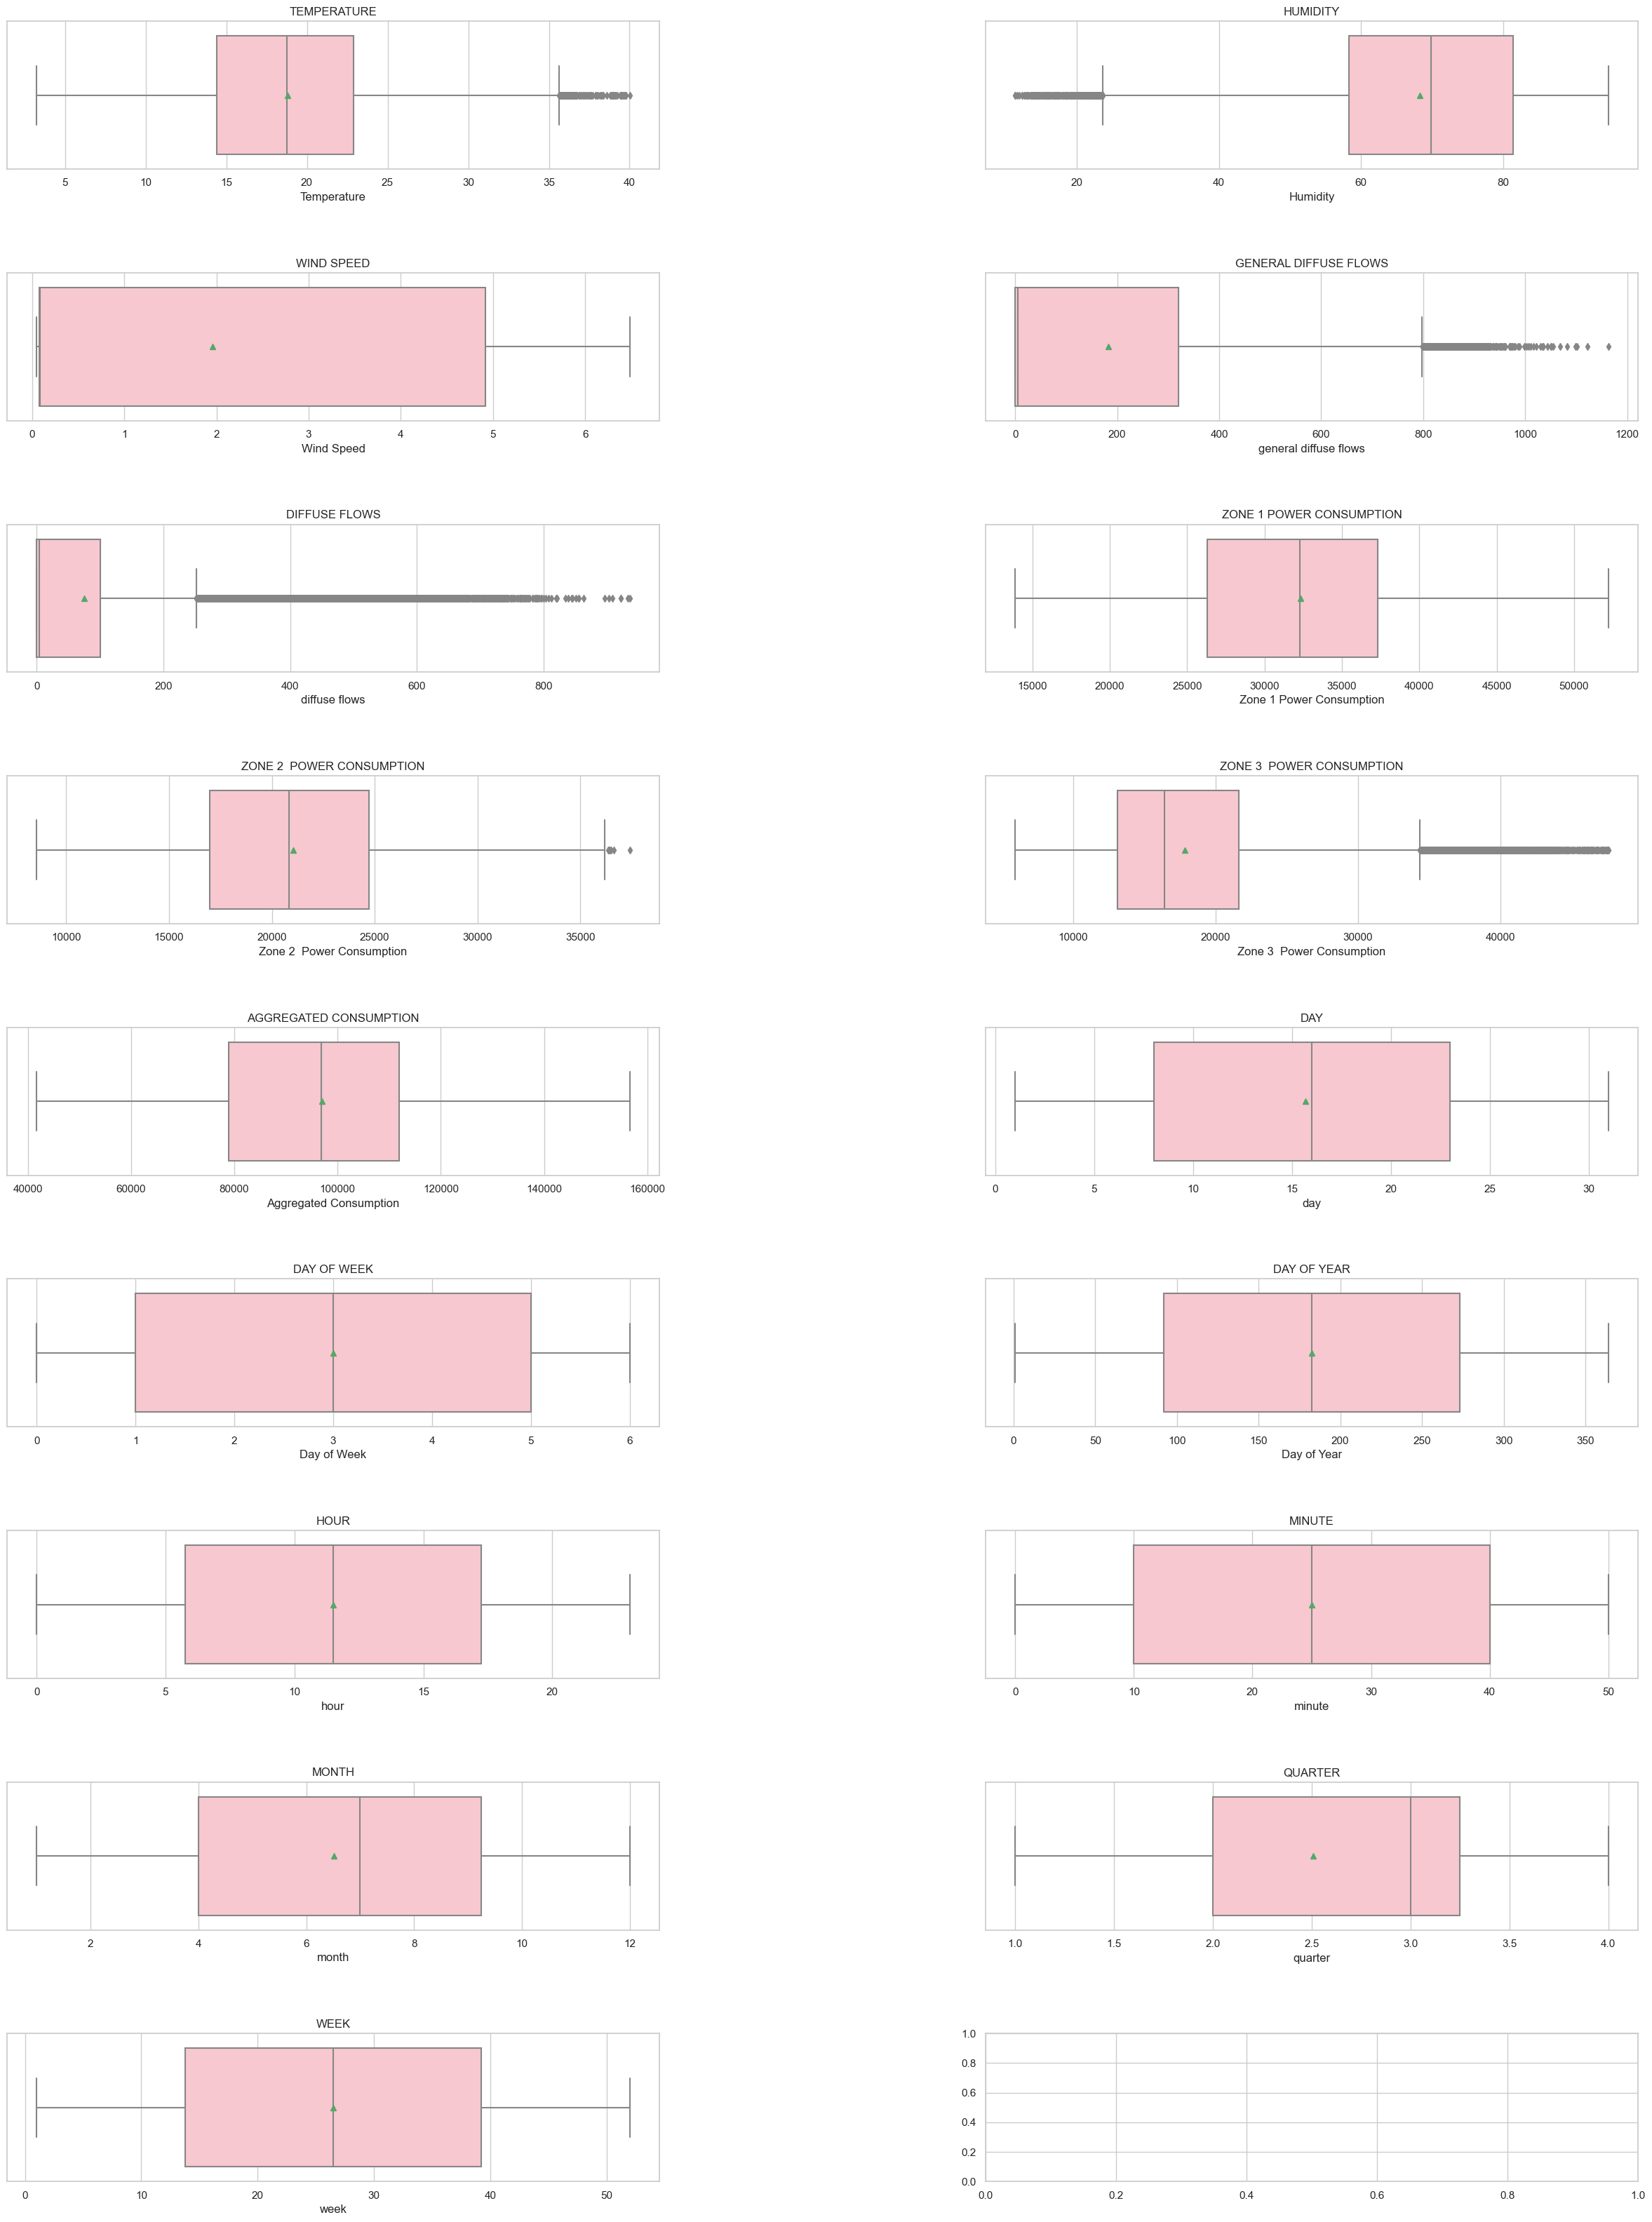

In [169]:
fig,axes = plt.subplots(9,2,figsize=(30,40))
plt.subplots_adjust(hspace=0.7,wspace=0.5)
for i,j in zip(num,axes.flatten()):
  sns.boxplot(x=i,data = df,ax=j,showmeans=True,color="pink")
  j.set_title(i.upper())

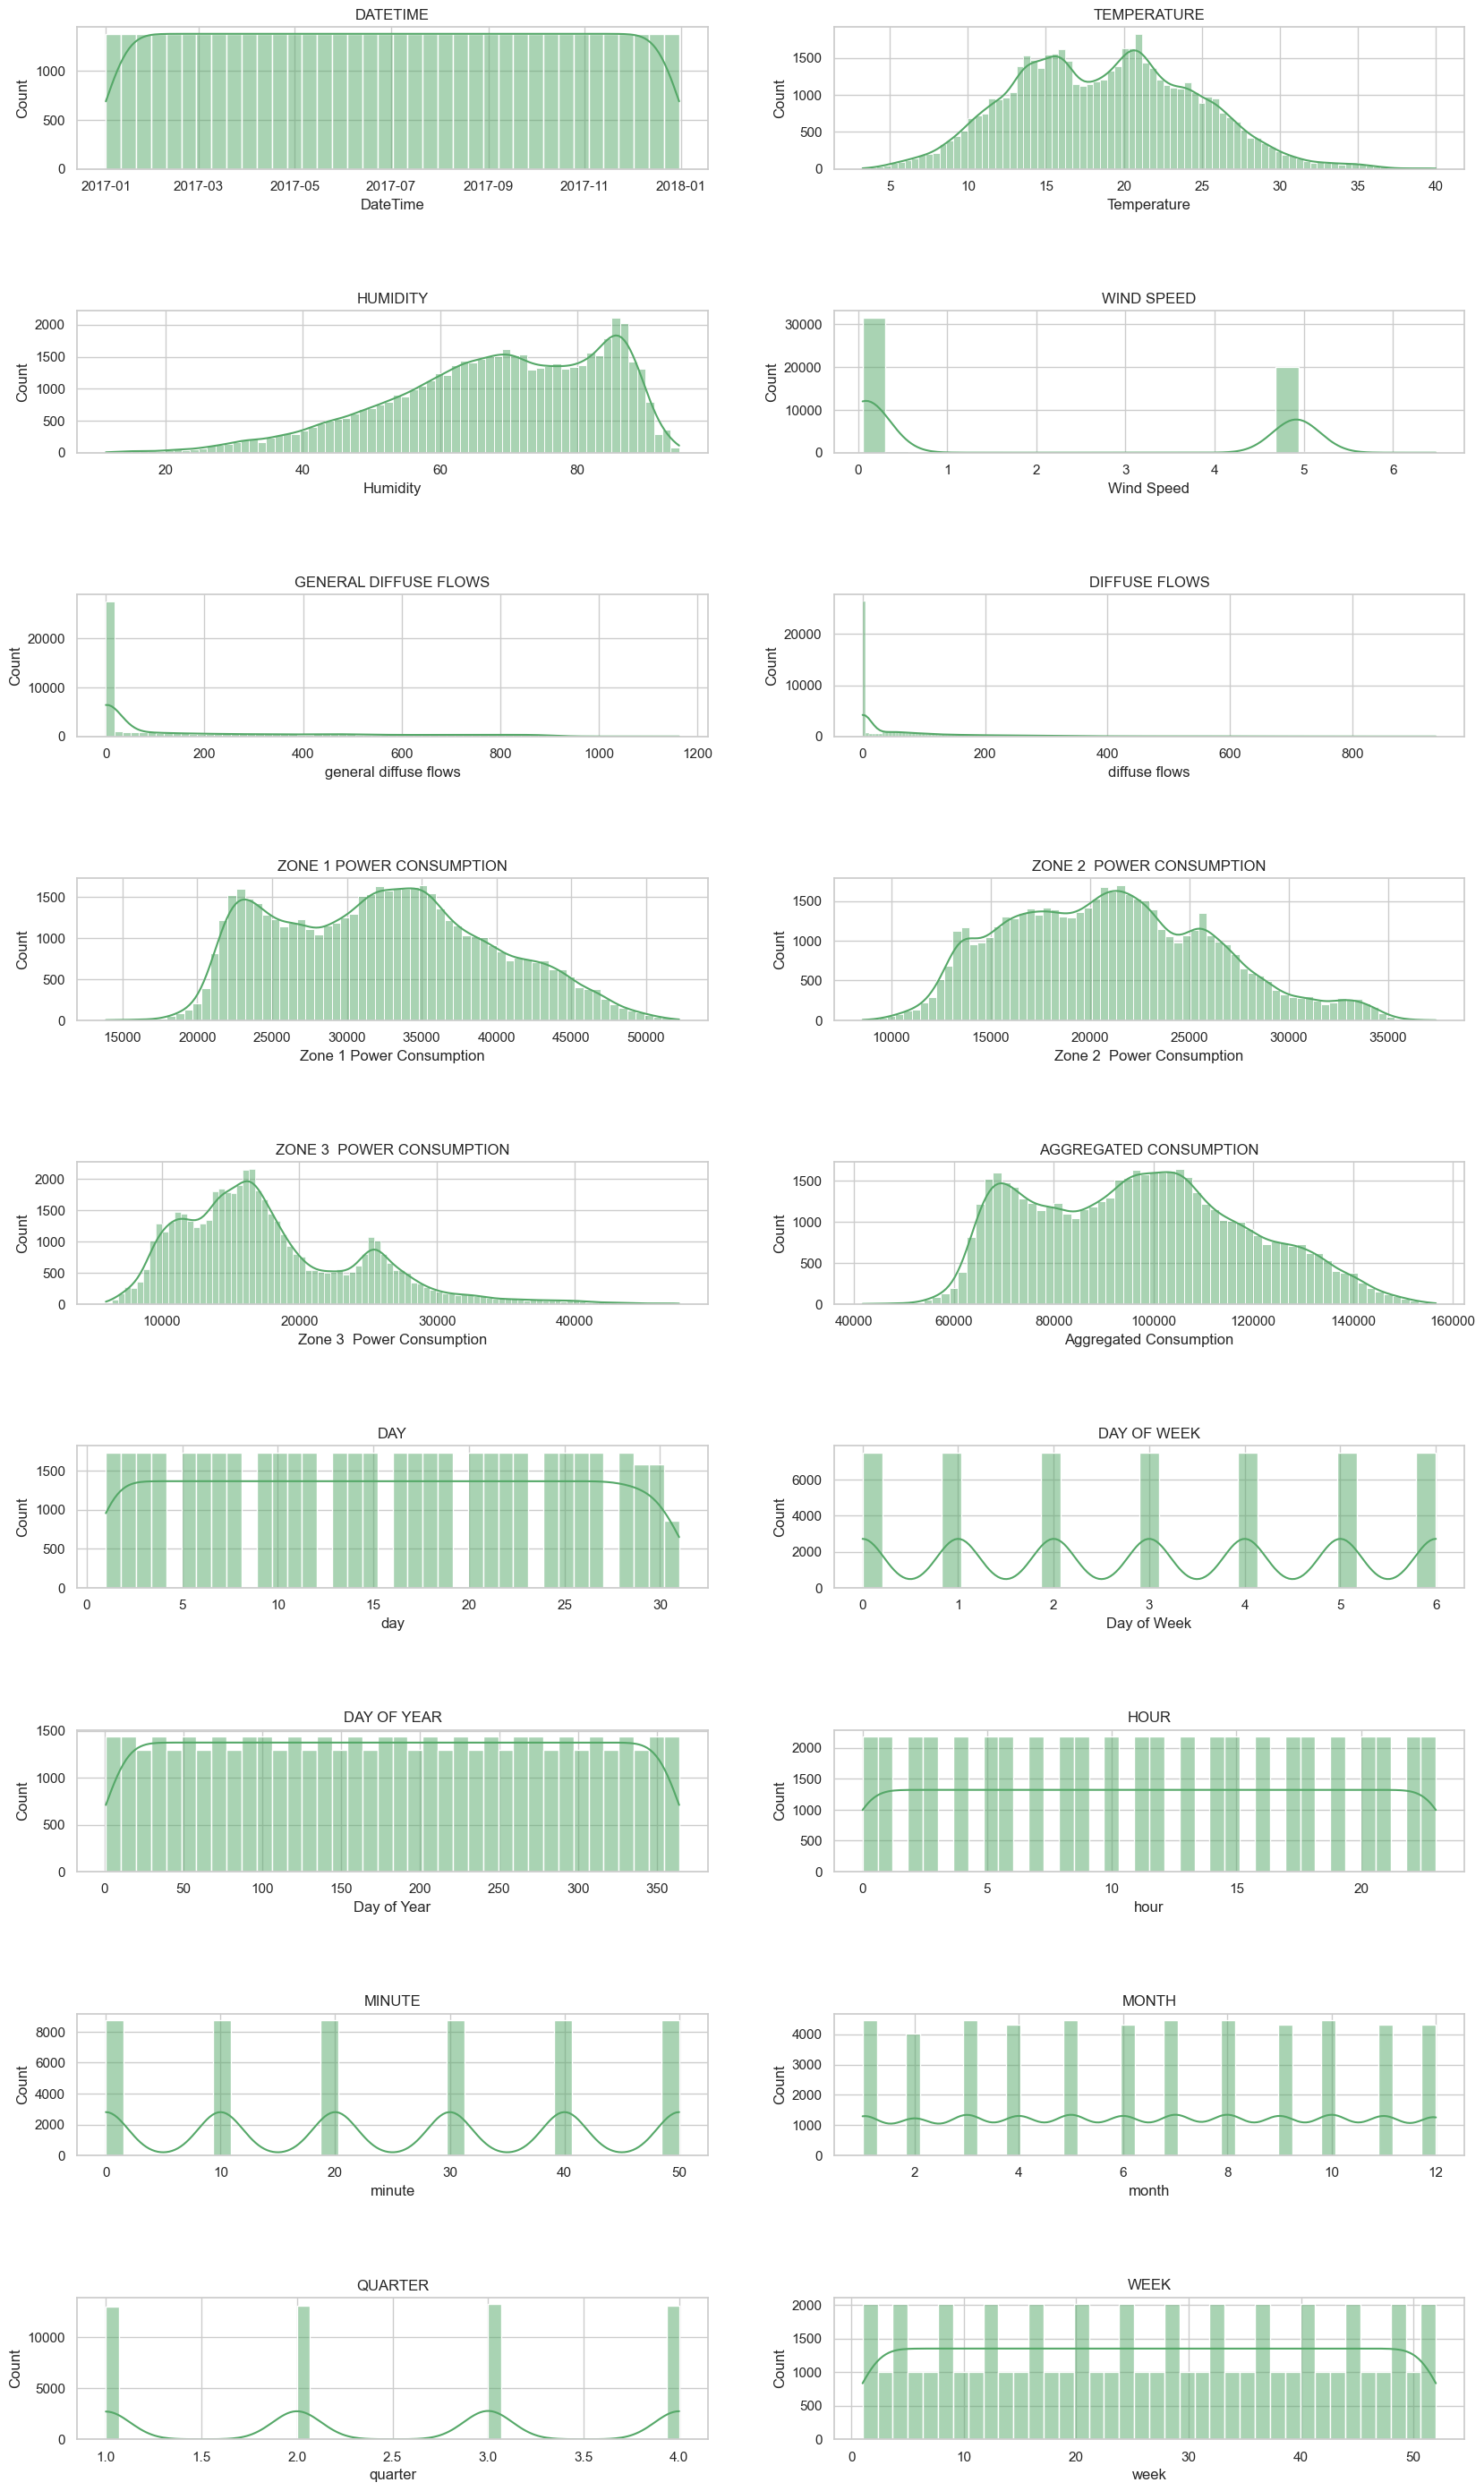

In [91]:
fig,axes = plt.subplots(9,2,figsize=(20,35))
plt.subplots_adjust(hspace=1,wspace=0.2)
for i,j in zip(num,axes.flatten()):
    sns.histplot(x=i,data = df,ax=j,kde=True,color='g')
    j.set_title(i.upper())

### Bivariate Analyisis

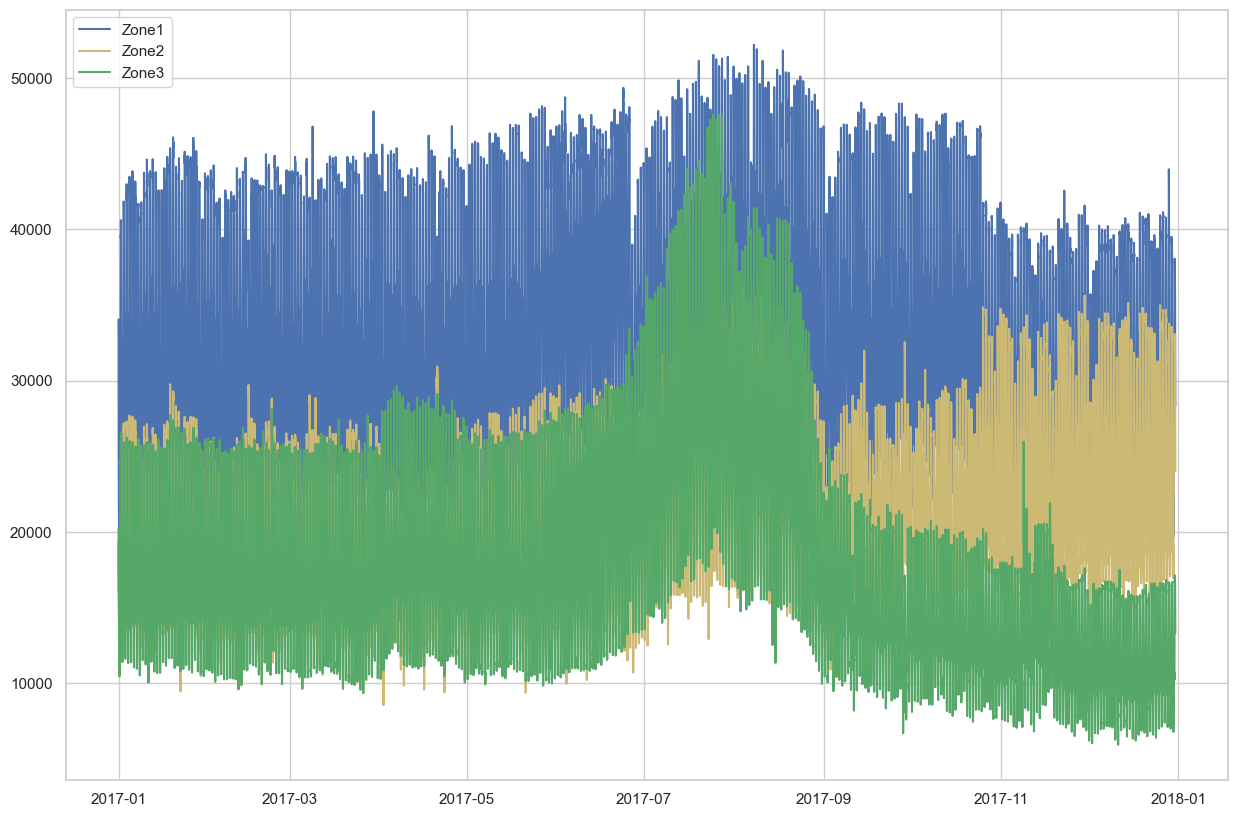

In [92]:
plt.figure(figsize=(15,10))
plt.plot( df["DateTime"], df[target1],'b-',label="Zone1")
plt.plot( df["DateTime"], df[target2],'y-',label="Zone2")
plt.plot( df["DateTime"], df[target3],'g-',label="Zone3")
plt.legend(loc="upper left")
plt.show()

<AxesSubplot:xlabel='Day of Week', ylabel='Zone 1 Power Consumption'>

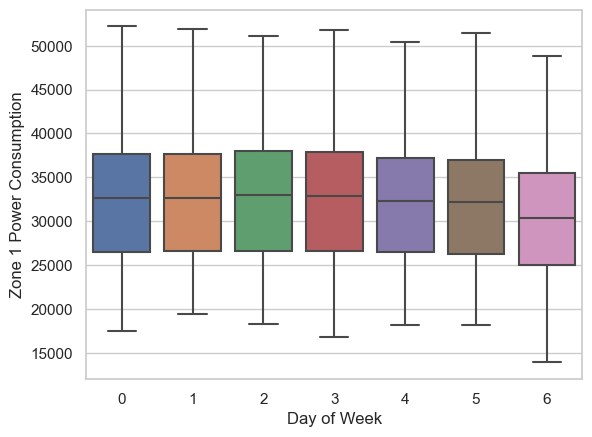

In [93]:
sns.boxplot(y=target1,data=df,x='Day of Week')

In [94]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour',
       'minute', 'month', 'quarter', 'week'],
      dtype='object')

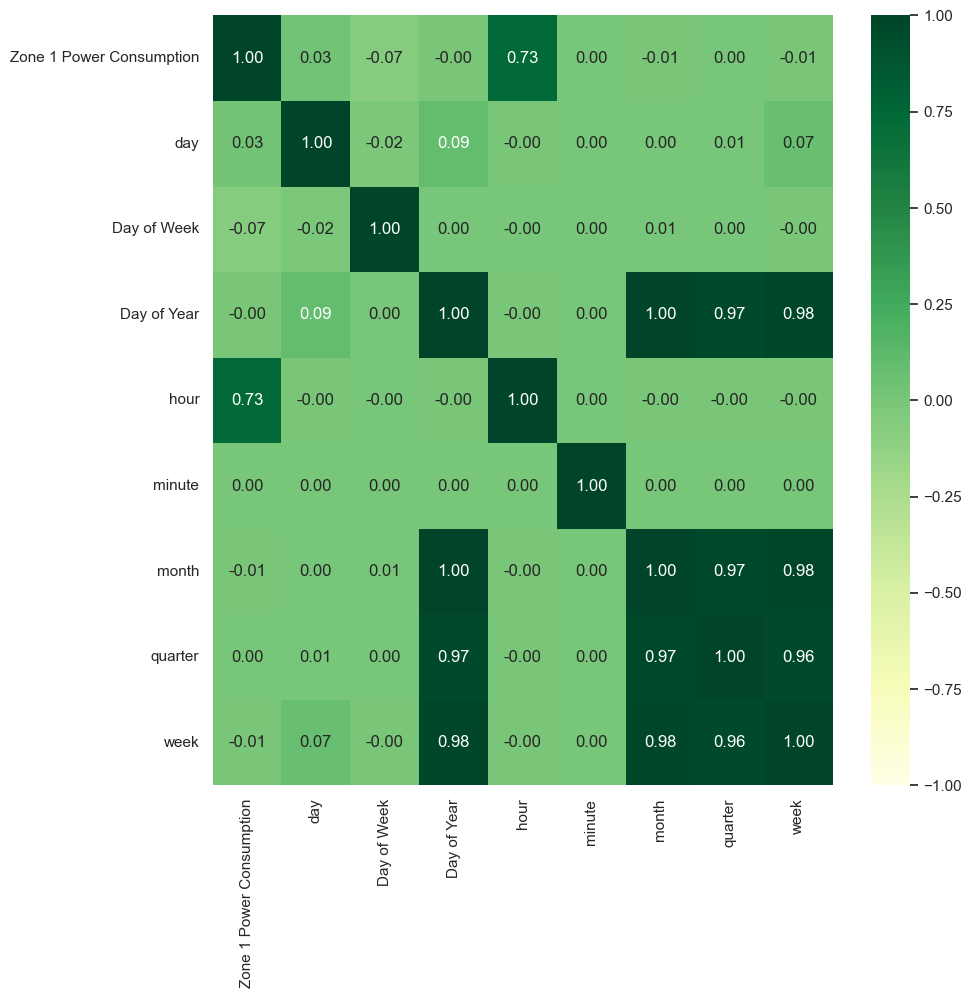

In [95]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target1,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

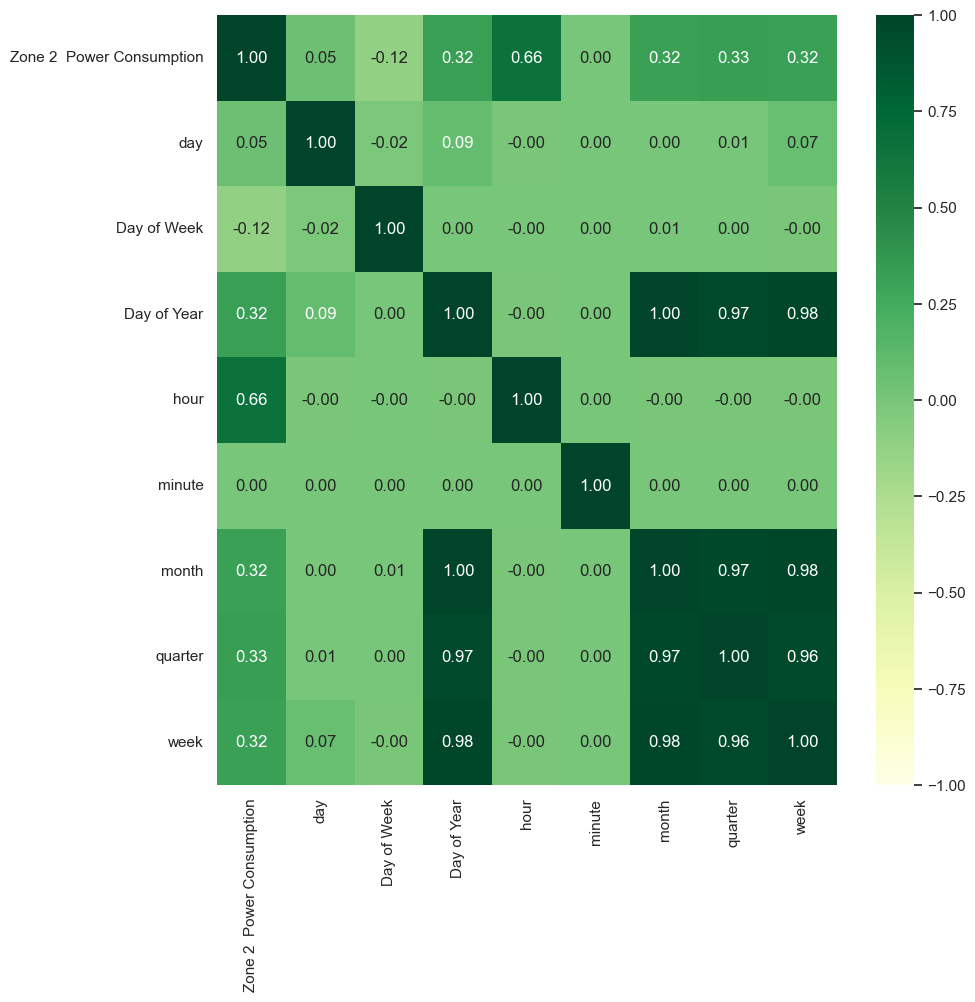

In [96]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target2,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

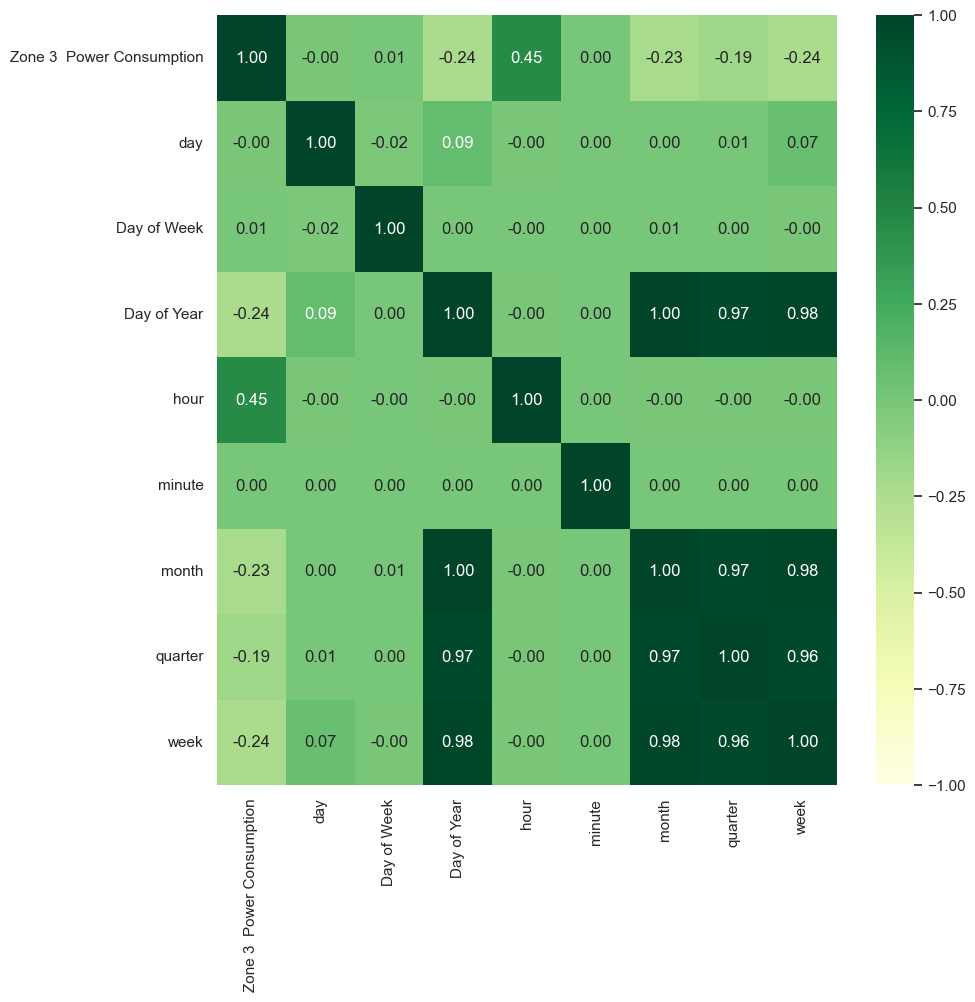

In [97]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target3,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

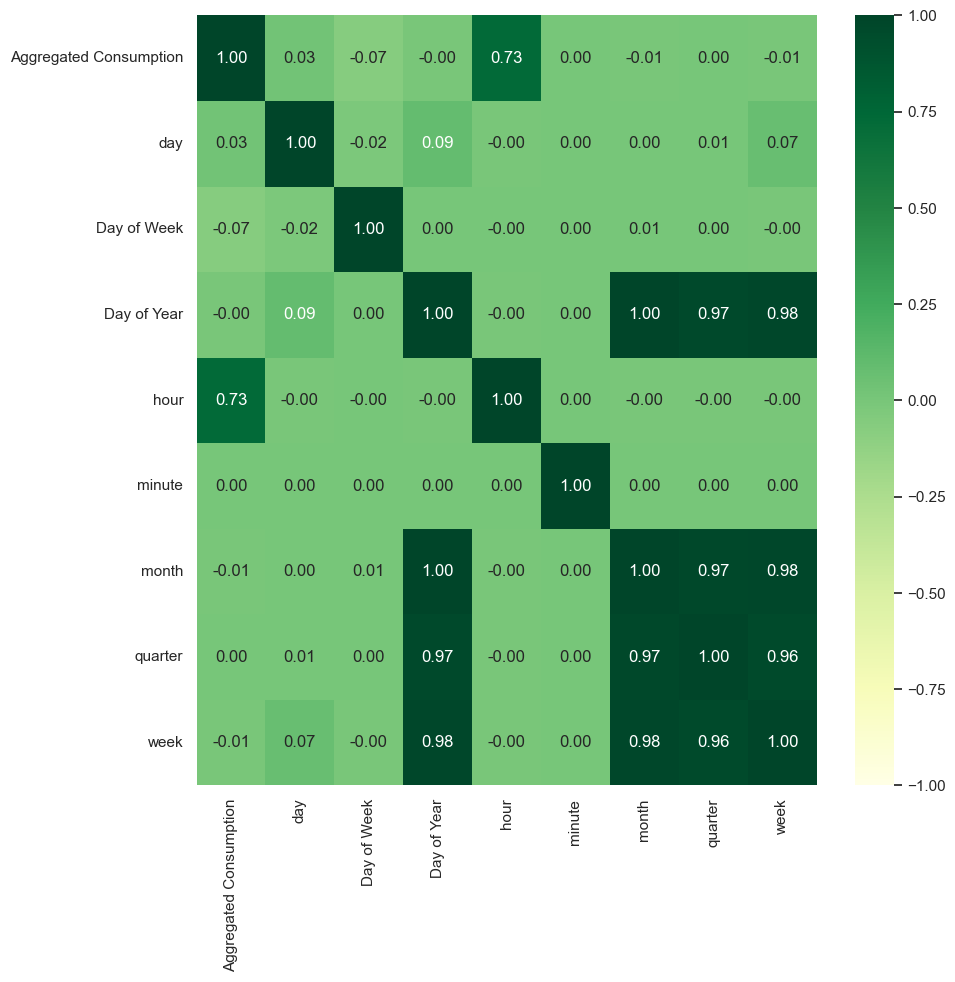

In [98]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target4,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

In [99]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour',
       'minute', 'month', 'quarter', 'week'],
      dtype='object')

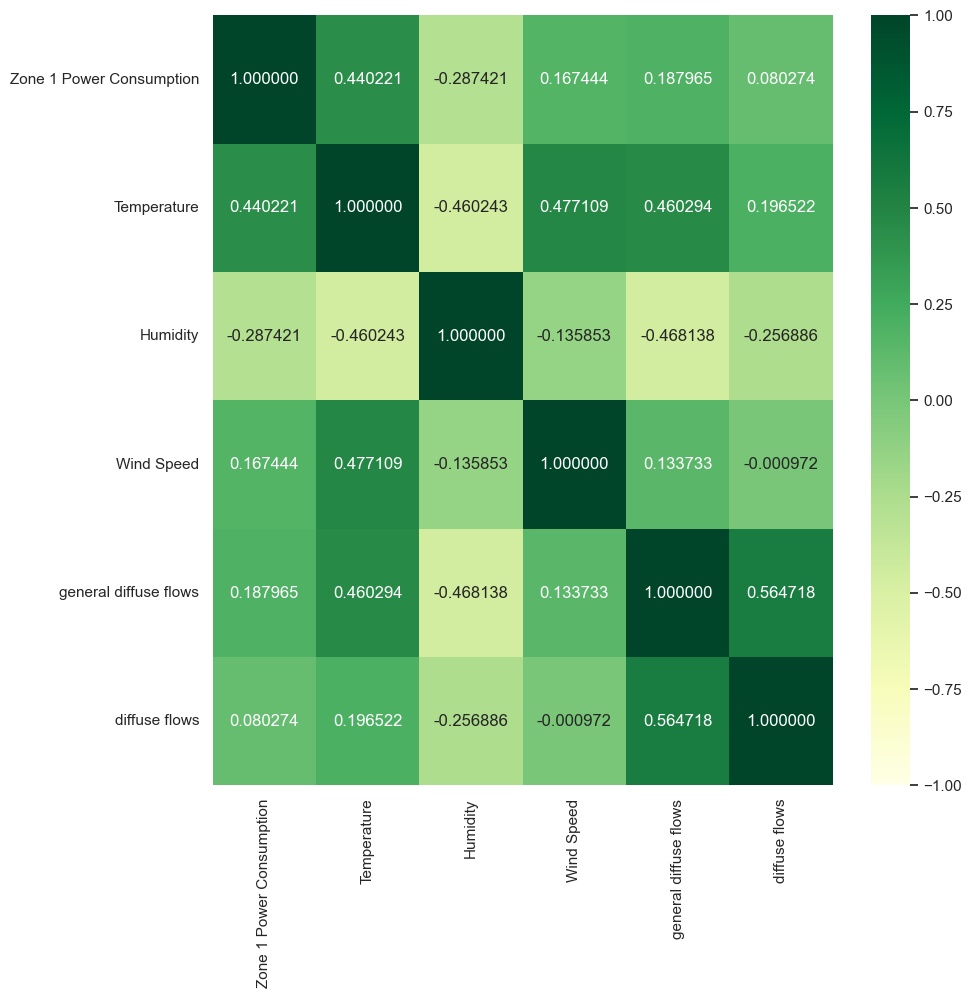

In [100]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target1,'Temperature', 'Humidity', 'Wind Speed','general diffuse flows', 'diffuse flows']].corr(), annot=True,fmt='.6f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

In [101]:
target_List=[target1,target2,target3,target4]

In [102]:
del df['DateTime']

# Scaling of variables.

In [103]:
df.columns.difference(target_List)

Index(['Day of Week', 'Day of Year', 'Humidity', 'Temperature', 'Wind Speed',
       'day', 'diffuse flows', 'general diffuse flows', 'hour', 'minute',
       'month', 'quarter', 'week'],
      dtype='object')

In [104]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()

In [114]:
X = df.drop(target_List,axis=1)
y1 = np.array(df[target1])
y2 = np.array(df[target2])
y3 = np.array(df[target3])
y4 = np.array(df[target4])

In [116]:
ipcols=X.columns
ipcols

Index(['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows',
       'diffuse flows', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute',
       'month', 'quarter', 'week'],
      dtype='object')

In [117]:
X=scalar.fit_transform(X)

In [118]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.25 , random_state=1)
_, _,  y2_train, y2_test = train_test_split(X, y2, test_size=0.25 , random_state=1)
_, _,  y3_train, y3_test = train_test_split(X, y3, test_size=0.25 , random_state=1)
_, _,  y4_train, y4_test = train_test_split(X, y4, test_size=0.25 , random_state=1)

## Feature Importance

In [125]:
from scipy.stats import chi2_contingency
for i in ipcols:
    contingency_table = pd.crosstab(df[i], df[target1])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    alpha = 0.01
    if p < alpha:
        print(f"{i} is significant because p value is :{p}.")
    else:
        print(f"{i} is NOT significant because p value is :{p} .")

Temperature is significant because p value is :6.953321730245835e-28.
Humidity is NOT significant because p value is :1.0 .
Wind Speed is significant because p value is :0.0.
general diffuse flows is significant because p value is :0.0.
diffuse flows is NOT significant because p value is :1.0 .
day is significant because p value is :3.7348745301717484e-33.
Day of Week is significant because p value is :2.1195033712390746e-11.
Day of Year is significant because p value is :0.0.
hour is significant because p value is :0.0.
minute is NOT significant because p value is :0.5736532440441496 .
month is significant because p value is :0.0.
quarter is significant because p value is :0.0.
week is significant because p value is :0.0.


In [119]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y1_train)

# Get feature importances
importances = model.feature_importances_
feature_names = ipcols
# Create a DataFrame with feature names and their importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the DataFrame
print(importance_df)

                  Feature  Importance
8                    hour    0.744250
7             Day of Year    0.084505
0             Temperature    0.083028
3   general diffuse flows    0.020838
6             Day of Week    0.015256
12                   week    0.013111
4           diffuse flows    0.010104
9                  minute    0.009012
5                     day    0.007599
1                Humidity    0.005531
2              Wind Speed    0.003194
10                  month    0.003043
11                quarter    0.000528


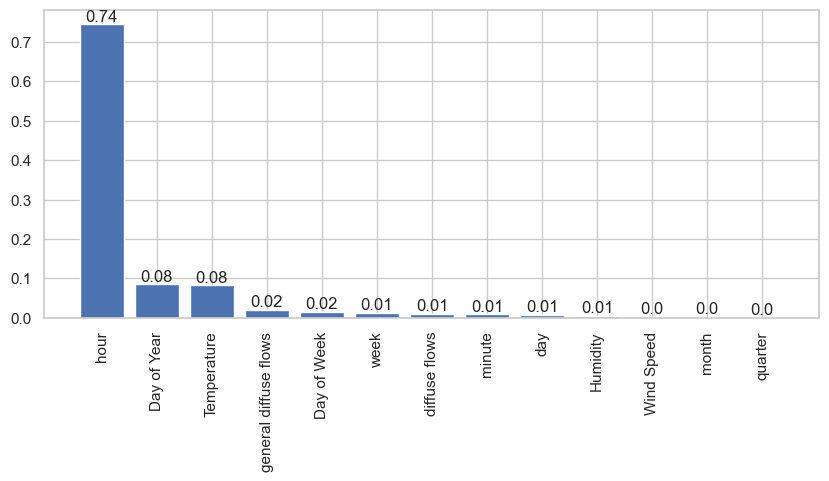

In [178]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(importance_df['Feature'], importance_df['Importance'])

# Add bar labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

ax.tick_params(axis='x', labelrotation=90)
plt.show()

# Model Preparation-10 minutes

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from keras import models, layers, optimizers, regularizers
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import statistics

In [45]:
target1='Zone 1 Power Consumption'
target2='Zone 2  Power Consumption'
target3='Zone 3  Power Consumption'
target4='Aggregated Consumption'

TrainRMSE=[]
TestRMSE=[]
TrainMAE=[]
TestMAE=[]
Target=[]

## FFNN

In [53]:
def FFNN(targets,y1_train,y1_test):
        modelname="FFNN"
        target=targets+"_10m_"+modelname
        FFNN_model = Sequential()
        FFNN_model.add(Dense(64, input_dim=X_train.shape[1], activation='selu'))  # First hidden layer with 64 neurons
        FFNN_model.add(Dense(10, activation='selu'))  # Second hidden layer with 32 neurons
        # FFNN_model.add(Dense(16, activation='relu'))  # Third hidden layer with 16 neurons
        FFNN_model.add(Dense(1, activation='selu'))  # Output layer for regression (single value prediction)

        # 4. Compile the FFNN_model with a custom learning rate
        learning_rate = 0.001  # Set the desired learning rate
        optimizer = Adam(learning_rate=learning_rate)

        # 4. Compile the FFNN_model
        FFNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

        early_stop = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=2, restore_best_weights=True )

        # 5. Train the FFNN_model
        history = FFNN_model.fit(X_train, y1_train, validation_split=0.25, epochs=100, batch_size=32, verbose=1, callbacks=[early_stop])

        # 6. Evaluate the FFNN_model
        loss, mae = FFNN_model.evaluate(X_test, y1_test)
        print(f"Mean Absolute Error on Test Data: {mae}")   
        
        rmse_tr=np.sqrt(mean_squared_error(y1_train,FFNN_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,FFNN_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,FFNN_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,FFNN_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [54]:
FFNN(target1,y1_train,y1_test)

Epoch 1/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - loss: 1055151168.0000 - mae: 31660.8555 - val_loss: 594383936.0000 - val_mae: 23359.6172
Epoch 2/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - loss: 387011040.0000 - mae: 17748.6777 - val_loss: 77649104.0000 - val_mae: 7054.3213
Epoch 3/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - loss: 75191104.0000 - mae: 6970.2856 - val_loss: 65001784.0000 - val_mae: 6467.4248
Epoch 4/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - loss: 62756520.0000 - mae: 6353.5767 - val_loss: 54699920.0000 - val_mae: 5904.7485
Epoch 5/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - loss: 53418196.0000 - mae: 5844.3320 - val_loss: 45086312.0000 - val_mae: 5332.1265
Epoch 6/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 44342868.0000 - mae: 5314.8955 - val_loss: 37047868.0000 - val_mae: 4829.9888
Epoch 7/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 35847844.0000 - mae: 4762.2051 - val_loss: 30642184.0000 - val_mae: 4378.7388
Epoch 

In [55]:
FFNN(target2,y2_train,y2_test)


Epoch 1/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - loss: 446355808.0000 - mae: 20451.5703 - val_loss: 198076432.0000 - val_mae: 13237.7725
Epoch 2/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - loss: 116318488.0000 - mae: 9356.1074 - val_loss: 26639840.0000 - val_mae: 4150.3887
Epoch 3/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step - loss: 25766830.0000 - mae: 4090.2253 - val_loss: 24336314.0000 - val_mae: 3966.9500
Epoch 4/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 23698878.0000 - mae: 3927.0417 - val_loss: 21849330.0000 - val_mae: 3754.7205
Epoch 5/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - loss: 21214638.0000 - mae: 3696.5232 - val_loss: 19328320.0000 - val_mae: 3522.7998
Epoch 6/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - loss: 18770582.0000 - mae: 3470.4314 - val_loss: 17063530.0000 - val_mae: 3308.1213
Epoch 7/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 16589329.0000 - mae: 3266.0857 - val_loss: 15131671.0000 - val_mae: 3110.6997
Epoch 8/10

In [56]:
FFNN(target3,y3_train,y3_test)


Epoch 1/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 348060832.0000 - mae: 17415.4023 - val_loss: 181808656.0000 - val_mae: 11639.3311
Epoch 2/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - loss: 121628696.0000 - mae: 8981.4805 - val_loss: 55895468.0000 - val_mae: 6038.1992
Epoch 3/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - loss: 53346148.0000 - mae: 5889.9141 - val_loss: 49301528.0000 - val_mae: 5594.9839
Epoch 4/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step - loss: 46891308.0000 - mae: 5467.7593 - val_loss: 43254484.0000 - val_mae: 5178.8081
Epoch 5/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 40571024.0000 - mae: 5035.8892 - val_loss: 37879904.0000 - val_mae: 4822.4014
Epoch 6/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - loss: 35773976.0000 - mae: 4688.8501 - val_loss: 33195344.0000 - val_mae: 4465.1367
Epoch 7/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - loss: 31373968.0000 - mae: 4344.6899 - val_loss: 29524318.0000 - val_mae: 4192.6753
Epoch 8/10

In [57]:
FFNN(target4,y4_train,y4_test)

Epoch 1/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9806067712.0000 - mae: 96690.9844 - val_loss: 8588562944.0000 - val_mae: 90224.8672
Epoch 2/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 7609723904.0000 - mae: 84463.7969 - val_loss: 3969594624.0000 - val_mae: 59295.6680
Epoch 3/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - loss: 2985368832.0000 - mae: 49347.3164 - val_loss: 977552704.0000 - val_mae: 25099.0469
Epoch 4/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 849796992.0000 - mae: 23426.8984 - val_loss: 680318976.0000 - val_mae: 21008.0957
Epoch 5/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - loss: 679136384.0000 - mae: 21017.3086 - val_loss: 612627136.0000 - val_mae: 19884.0156
Epoch 6/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - loss: 597573248.0000 - mae: 19653.5996 - val_loss: 540541952.0000 - val_mae: 18577.1738
Epoch 7/100
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - loss: 536020288.0000 - mae: 18583.3867 - val_loss: 471078784.0000 - va

In [58]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415


## Linear Regression

In [59]:
def LR(targets,y1_train,y1_test):
        model="Linear Regression"
        target=targets+"_10m_"+model
        LR_model=LinearRegression()
        LR_model.fit(X_train,y1_train)

        rmse_tr=np.sqrt(mean_squared_error(y1_train,LR_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,LR_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,LR_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,LR_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [60]:
LR(target1,y1_train,y1_test)
LR(target2,y2_train,y2_test)
LR(target3,y3_train,y3_test)
LR(target4,y4_train,y4_test)

In [61]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614


## Random Forest

In [62]:
def RF(targets,y1_train,y1_test):
        model="Random Forest"
        target=targets+"_10m_"+model
        model_RF = RandomForestRegressor(random_state=1)
        params_RF = {
                'n_estimators':[10,20, 30, 50, 100, 200, 300],
                'min_samples_split':list(range(1,3)),
                'max_features':list(range(1,10)),
                'min_samples_leaf':list(range(1,3))}
        grid_search_RF = GridSearchCV(estimator = model_RF, param_grid = params_RF, cv = 10,n_jobs=-1,verbose=2)
        grid_search_RF.fit(X_train,y1_train)
        RF_model = grid_search_RF.best_estimator_
        grid_search_RF.best_params_



        rmse_tr=np.sqrt(mean_squared_error(y1_train,RF_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,RF_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,RF_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,RF_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)


In [63]:
def RF(targets,y1_train,y1_test):
        model="Random Forest"
        target=targets+"_10m_"+model
        RF_model = RandomForestRegressor(max_features=3, min_samples_split=2, n_estimators=50, max_depth=None, min_samples_leaf=1)
        RF_model.fit(X_train,y1_train)

        rmse_tr=np.sqrt(mean_squared_error(y1_train,RF_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,RF_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,RF_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,RF_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)


In [64]:
RF(target1,y1_train,y1_test)
RF(target2,y2_train,y2_test)
RF(target3,y3_train,y3_test)
RF(target4,y4_train,y4_test)

In [65]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## Decision Tree

In [66]:
def DT(targets,y1_train,y1_test):
        model="Decision Tree"
        target=targets+"_10m_"+model
        model_DT = DecisionTreeRegressor(random_state=1)
        params_DT = {
         'max_depth':list(range(400,501)),
         'min_samples_split':list(range(101,201)),
         'min_samples_leaf':list(range(10,20)),
         'max_features':list(range(1,10))}
        grid_search_DT = GridSearchCV(estimator = model_DT, param_grid = params_DT, cv = 10,n_jobs=-1,verbose=2)
        grid_search_DT.fit(X_train,y1_train)
        DT_model = grid_search_DT.best_estimator_
        grid_search_DT.best_params_



        rmse_tr=np.sqrt(mean_squared_error(y1_train,DT_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,DT_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,DT_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,DT_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [67]:
def DT(targets,y1_train,y1_test):
        model="Decision Tree"
        target=targets+"_10m_"+model
        DT_model=DecisionTreeRegressor(min_samples_leaf=10,min_samples_split=10,max_features=9)
        DT_model.fit(X_train,y1_train)

        rmse_tr=np.sqrt(mean_squared_error(y1_train,DT_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,DT_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,DT_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,DT_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [68]:
DT(target1,y1_train,y1_test)
DT(target2,y2_train,y2_test)
DT(target3,y3_train,y3_test)
DT(target4,y4_train,y4_test)

In [69]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## SVR

In [72]:
def SVRM(targets,y1_train,y1_test):
        model="Support Vector Regressor"
        target=targets+"_10m_"+model
        SVR_model=SVR(kernel='rbf',C=10.0,gamma=0.01)
        SVR()
        SVR_model.fit(X_train,y1_train)

        rmse_tr=np.sqrt(mean_squared_error(y1_train,SVR_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,SVR_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,SVR_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,SVR_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [73]:
SVRM(target1,y1_train,y1_test)


In [74]:
SVRM(target2,y2_train,y2_test)


In [75]:
SVRM(target3,y3_train,y3_test)


In [76]:
SVRM(target4,y4_train,y4_test)

In [77]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


# Model Preparation-1 hour model

In [79]:
df_Hourly

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,month,quarter,week
DateTime,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,2017-01-01 00:25:00,6.196833,75.066667,0.081833,0.063500,0.098833,175187.84810,108160.48632,115512.28916,525563.54430,1,6,1,0,1,1,52
2017-01-01 01:00:00,2017-01-01 01:25:00,5.548833,77.583333,0.082000,0.056833,0.112500,147943.29114,96470.51672,102257.34940,443829.87342,1,6,1,1,1,1,52
2017-01-01 02:00:00,2017-01-01 02:25:00,5.054333,78.933333,0.082333,0.063000,0.129167,132498.22784,85984.19453,94056.86747,397494.68352,1,6,1,2,1,1,52
2017-01-01 03:00:00,2017-01-01 03:25:00,5.004333,77.083333,0.082833,0.059833,0.141000,124866.83544,79316.71732,89303.13253,374600.50632,1,6,1,3,1,1,52
2017-01-01 04:00:00,2017-01-01 04:25:00,5.097667,74.050000,0.082333,0.058000,0.122833,122855.69620,77529.48328,85902.65060,368567.08860,1,6,1,4,1,1,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-30 19:00:00,2017-12-30 19:25:00,9.453333,62.406667,0.074667,0.052000,0.102000,225082.88974,194986.19208,101560.62425,675248.66922,30,5,364,19,12,4,52
2017-12-30 20:00:00,2017-12-30 20:25:00,9.041667,63.990000,0.080333,0.052667,0.105000,222053.23193,192121.50966,101992.79712,666159.69579,30,5,364,20,12,4,52
2017-12-30 21:00:00,2017-12-30 21:25:00,8.011667,69.675000,0.081500,0.073167,0.098333,212149.04943,184547.40718,99653.30132,636447.14829,30,5,364,21,12,4,52


In [80]:
del df_Hourly['DateTime']

In [85]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()

In [86]:
X = df_Hourly.drop(target_List,axis=1)
y1 = np.array(df_Hourly[target1])
y2 = np.array(df_Hourly[target2])
y3 = np.array(df_Hourly[target3])
y4 = np.array(df_Hourly[target4])

In [87]:
X=scalar.fit_transform(X)

In [88]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.25 , random_state=1)
_, _,  y2_train, y2_test = train_test_split(X, y2, test_size=0.25 , random_state=1)
_, _,  y3_train, y3_test = train_test_split(X, y3, test_size=0.25 , random_state=1)
_, _,  y4_train, y4_test = train_test_split(X, y4, test_size=0.25 , random_state=1)

## FFNN

In [89]:
FFNN_model = Sequential()
FFNN_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer with 64 neurons
FFNN_model.add(Dense(25, activation='relu'))  # Second hidden layer with 32 neurons
# FFNN_model.add(Dense(16, activation='relu'))  # Third hidden layer with 16 neurons
FFNN_model.add(Dense(1, activation='relu'))  # Output layer for regression (single value prediction)

# 4. Compile the Model with SGD Optimizer
learning_rate = 0.01  # Set the desired learning rate
momentum = 0.9  # Set momentum for SGD (optional)
optimizer = SGD(learning_rate=learning_rate, momentum=momentum)

# 4. Compile the FFNN_model
FFNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=2, restore_best_weights=True )

# 5. Train the FFNN_model
history = FFNN_model.fit(X_train, y1_train, validation_split=0.25, epochs=100, batch_size=100, verbose=1, callbacks=[early_stop])

# 6. Evaluate the FFNN_model
loss, mae = FFNN_model.evaluate(X_test, y1_test)
print(f"Mean Absolute Error on Test Data: {mae}")   

rmse_tr=np.sqrt(mean_squared_error(y1_train,FFNN_model.predict(X_train)))
mae_tr=mean_absolute_error(y1_train,FFNN_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y1_test,FFNN_model.predict(X_test)))
mae_te=mean_absolute_error(y1_test,FFNN_model.predict(X_test))

Target.append(target1+"_1H_FFNN")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 212781767994638336.0000 - mae: 119707688.0000 - val_loss: 39161262080.0000 - val_mae: 193230.6562
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39970598912.0000 - mae: 195435.4531 - val_loss: 39161262080.0000 - val_mae: 193230.6562
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 39505735680.0000 - mae: 194291.4531 - val_loss: 39161262080.0000 - val_mae: 193230.6562
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 39196504064.0000 - mae: 193564.0938
Mean Absolute Error on Test Data: 194361.6875
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step


In [90]:
FFNN_model = Sequential()
FFNN_model.add(Dense(64, input_dim=X_train.shape[1], activation='selu'))  # First hidden layer with 64 neurons
FFNN_model.add(Dense(4, activation='selu'))  # Second hidden layer with 32 neurons
# FFNN_model.add(Dense(16, activation='relu'))  # Third hidden layer with 16 neurons
FFNN_model.add(Dense(1, activation='selu'))  # Output layer for regression (single value prediction)

# 4. Compile the FFNN_model with a custom learning rate
learning_rate = 0.001  # Set the desired learning rate
optimizer = Adam(learning_rate=learning_rate)

# 4. Compile the FFNN_model
FFNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=2, restore_best_weights=True )

# 5. Train the FFNN_model
history = FFNN_model.fit(X_train, y2_train, validation_split=0.25, epochs=100, batch_size=350, verbose=1, callbacks=[early_stop])

# 6. Evaluate the FFNN_model
loss, mae = FFNN_model.evaluate(X_test, y2_test)
print(f"Mean Absolute Error on Test Data: {mae}")   

rmse_tr=np.sqrt(mean_squared_error(y2_train,FFNN_model.predict(X_train)))
mae_tr=mean_absolute_error(y2_train,FFNN_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y2_test,FFNN_model.predict(X_test)))
mae_te=mean_absolute_error(y2_test,FFNN_model.predict(X_test))

Target.append(target2+"_1H_FFNN")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 16671037440.0000 - mae: 125444.6250 - val_loss: 16814264320.0000 - val_mae: 125847.5312
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16974582784.0000 - mae: 126548.8203 - val_loss: 16813677568.0000 - val_mae: 125845.2578
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16809795584.0000 - mae: 125908.0078 - val_loss: 16813085696.0000 - val_mae: 125842.9531
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16933012480.0000 - mae: 126420.2500 - val_loss: 16812408832.0000 - val_mae: 125840.3359
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16948221952.0000 - mae: 126442.7656 - val_loss: 16811619328.0000 - val_mae: 125837.2344
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17002682368.0000 - mae: 126631.4375 - val_loss: 16810674176.0000 - val_mae: 125833.5625
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16982505472.0000 - mae: 126668.0938 - val_loss: 16809549824

In [91]:
FFNN_model = Sequential()
FFNN_model.add(Dense(64, input_dim=X_train.shape[1], activation='selu'))  # First hidden layer with 64 neurons
FFNN_model.add(Dense(8, activation='selu'))  # Second hidden layer with 32 neurons
# FFNN_model.add(Dense(16, activation='relu'))  # Third hidden layer with 16 neurons
FFNN_model.add(Dense(1, activation='selu'))  # Output layer for regression (single value prediction)

# 4. Compile the FFNN_model with a custom learning rate
learning_rate = 0.001  # Set the desired learning rate
optimizer = Adam(learning_rate=learning_rate)

# 4. Compile the FFNN_model
FFNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=2, restore_best_weights=True )

# 5. Train the FFNN_model
history = FFNN_model.fit(X_train, y3_train, validation_split=0.25, epochs=100, batch_size=250, verbose=1, callbacks=[early_stop])

# 6. Evaluate the FFNN_model
loss, mae = FFNN_model.evaluate(X_test, y3_test)
print(f"Mean Absolute Error on Test Data: {mae}")   

rmse_tr=np.sqrt(mean_squared_error(y3_train,FFNN_model.predict(X_train)))
mae_tr=mean_absolute_error(y3_train,FFNN_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y3_test,FFNN_model.predict(X_test)))
mae_te=mean_absolute_error(y3_test,FFNN_model.predict(X_test))

Target.append(target3+"_1H_FFNN")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 13007355904.0000 - mae: 107045.2266 - val_loss: 12864641024.0000 - val_mae: 106223.7734
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13140879360.0000 - mae: 107561.5547 - val_loss: 12863986688.0000 - val_mae: 106220.6875
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13221020672.0000 - mae: 107934.2266 - val_loss: 12863156224.0000 - val_mae: 106216.7891
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13078666240.0000 - mae: 107380.5625 - val_loss: 12862064640.0000 - val_mae: 106211.6641
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12906412032.0000 - mae: 106666.5781 - val_loss: 12860587008.0000 - val_mae: 106204.7188
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12946273280.0000 - mae: 106682.9219 - val_loss: 12858592256.0000 - val_mae: 106195.3438
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13230426112.0000 - mae: 107814.3906 - val_loss: 12855967744

In [92]:
FFNN_model = Sequential()
FFNN_model.add(Dense(64, input_dim=X_train.shape[1], activation='selu'))  # First hidden layer with 64 neurons
FFNN_model.add(Dense(4, activation='selu'))  # Second hidden layer with 32 neurons
# FFNN_model.add(Dense(16, activation='relu'))  # Third hidden layer with 16 neurons
FFNN_model.add(Dense(1, activation='selu'))  # Output layer for regression (single value prediction)

# 4. Compile the FFNN_model with a custom learning rate
learning_rate = 0.001  # Set the desired learning rate
optimizer = Adam(learning_rate=learning_rate)

# 4. Compile the FFNN_model
FFNN_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=2, restore_best_weights=True )

# 5. Train the FFNN_model
history = FFNN_model.fit(X_train, y4_train, validation_split=0.25, epochs=100, batch_size=250, verbose=1, callbacks=[early_stop])

# 6. Evaluate the FFNN_model
loss, mae = FFNN_model.evaluate(X_test, y4_test)
print(f"Mean Absolute Error on Test Data: {mae}")   

rmse_tr=np.sqrt(mean_squared_error(y4_train,FFNN_model.predict(X_train)))
mae_tr=mean_absolute_error(y4_train,FFNN_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y4_test,FFNN_model.predict(X_test)))
mae_te=mean_absolute_error(y4_test,FFNN_model.predict(X_test))

Target.append(target4+"_1H_FFNN")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 355457794048.0000 - mae: 582641.1875 - val_loss: 352448905216.0000 - val_mae: 579689.8750
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 354759278592.0000 - mae: 582077.3750 - val_loss: 352445726720.0000 - val_mae: 579687.1250
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 357776687104.0000 - mae: 584482.5000 - val_loss: 352441565184.0000 - val_mae: 579683.6875
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 353728626688.0000 - mae: 581196.3125 - val_loss: 352436289536.0000 - val_mae: 579679.1250
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 355320791040.0000 - mae: 582088.8750 - val_loss: 352429342720.0000 - val_mae: 579673.1875
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 352741687296.0000 - mae: 580284.8750 - val_loss: 352420593664.0000 - val_mae: 579665.8125
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 356207493120.0000 - mae: 583202.9375 - val_loss

In [93]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## Linear Regression

In [94]:
def LR(targets,y1_train,y1_test):
        model="Linear Regression"
        target=targets+"_1H"+"_"+model
        LR_model=LinearRegression()
        LR_model.fit(X_train,y1_train)

        rmse_tr=np.sqrt(mean_squared_error(y1_train,LR_model.predict(X_train)))
        mae_tr=mean_absolute_error(y1_train,LR_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y1_test,LR_model.predict(X_test)))
        mae_te=mean_absolute_error(y1_test,LR_model.predict(X_test))

        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)

In [95]:
LR(target1,y1_train,y1_test)
LR(target2,y2_train,y2_test)
LR(target3,y3_train,y3_test)
LR(target4,y4_train,y4_test)

In [96]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## Random Forest

In [97]:
RF_model = RandomForestRegressor(max_features=3, min_samples_split=2, n_estimators=50, max_depth=None, min_samples_leaf=1)
RF_model.fit(X_train,y1_train)
rmse_tr=np.sqrt(mean_squared_error(y1_train,RF_model.predict(X_train)))
mae_tr=mean_absolute_error(y1_train,RF_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y1_test,RF_model.predict(X_test)))
mae_te=mean_absolute_error(y1_test,RF_model.predict(X_test))

Target.append(target1+"_1H_Random Forest")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)


In [98]:
RF_model = RandomForestRegressor(max_features=7, min_samples_split=3, n_estimators=10, max_depth=None, min_samples_leaf=1)
RF_model.fit(X_train,y2_train)
rmse_tr=np.sqrt(mean_squared_error(y2_train,RF_model.predict(X_train)))
mae_tr=mean_absolute_error(y2_train,RF_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y2_test,RF_model.predict(X_test)))
mae_te=mean_absolute_error(y2_test,RF_model.predict(X_test))

Target.append(target2+"_1H_Random Forest")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [99]:
RF_model = RandomForestRegressor(max_features=7, min_samples_split=3, n_estimators=10, max_depth=None, min_samples_leaf=10)
RF_model.fit(X_train,y3_train)
rmse_tr=np.sqrt(mean_squared_error(y3_train,RF_model.predict(X_train)))
mae_tr=mean_absolute_error(y3_train,RF_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y3_test,RF_model.predict(X_test)))
mae_te=mean_absolute_error(y3_test,RF_model.predict(X_test))

Target.append(target3+"_1H_Random Forest")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [100]:
RF_model = RandomForestRegressor(max_features=5, min_samples_split=2, n_estimators=100, max_depth=None, min_samples_leaf=1)
RF_model.fit(X_train,y4_train)
rmse_tr=np.sqrt(mean_squared_error(y4_train,RF_model.predict(X_train)))
mae_tr=mean_absolute_error(y4_train,RF_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y4_test,RF_model.predict(X_test)))
mae_te=mean_absolute_error(y4_test,RF_model.predict(X_test))

Target.append(target4+"_1H_Random Forest")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [101]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## Decision Tree

In [102]:
DT_model=DecisionTreeRegressor(min_samples_leaf=10,min_samples_split=2,max_features=5)
DT_model.fit(X_train,y1_train)

rmse_tr=np.sqrt(mean_squared_error(y1_train,DT_model.predict(X_train)))
mae_tr=mean_absolute_error(y1_train,DT_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y1_test,DT_model.predict(X_test)))
mae_te=mean_absolute_error(y1_test,DT_model.predict(X_test))

Target.append(target1+"_1H_Decision Tree")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [103]:
DT_model=DecisionTreeRegressor(min_samples_leaf=10,min_samples_split=3,max_features=7)
DT_model.fit(X_train,y2_train)

rmse_tr=np.sqrt(mean_squared_error(y2_train,DT_model.predict(X_train)))
mae_tr=mean_absolute_error(y2_train,DT_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y2_test,DT_model.predict(X_test)))
mae_te=mean_absolute_error(y2_test,DT_model.predict(X_test))

Target.append(target2+"_1H_Decision Tree")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [104]:
DT_model=DecisionTreeRegressor(min_samples_leaf=10,min_samples_split=2,max_features=9)
DT_model.fit(X_train,y3_train)

rmse_tr=np.sqrt(mean_squared_error(y3_train,DT_model.predict(X_train)))
mae_tr=mean_absolute_error(y3_train,DT_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y3_test,DT_model.predict(X_test)))
mae_te=mean_absolute_error(y3_test,DT_model.predict(X_test))

Target.append(target3+"_1H_Decision Tree")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [105]:
DT_model=DecisionTreeRegressor(min_samples_leaf=3,min_samples_split=3,max_features=9)
DT_model.fit(X_train,y4_train)

rmse_tr=np.sqrt(mean_squared_error(y4_train,DT_model.predict(X_train)))
mae_tr=mean_absolute_error(y4_train,DT_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y4_test,DT_model.predict(X_test)))
mae_te=mean_absolute_error(y4_test,DT_model.predict(X_test))

Target.append(target4+"_1H_Decision Tree")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [106]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## SVR

In [107]:
SVR_model=SVR(C=10,gamma=0.01)
SVR_model.fit(X_train,y1_train)

rmse_tr=np.sqrt(mean_squared_error(y1_train,SVR_model.predict(X_train)))
mae_tr=mean_absolute_error(y1_train,SVR_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y1_test,SVR_model.predict(X_test)))
mae_te=mean_absolute_error(y1_test,SVR_model.predict(X_test))

Target.append(target1+"_1H_Support Vector Regressor")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [108]:
SVR_model=SVR(C=1.0,gamma=0.01)
SVR_model.fit(X_train,y2_train)

rmse_tr=np.sqrt(mean_squared_error(y2_train,SVR_model.predict(X_train)))
mae_tr=mean_absolute_error(y2_train,SVR_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y2_test,SVR_model.predict(X_test)))
mae_te=mean_absolute_error(y2_test,SVR_model.predict(X_test))

Target.append(target2+"_1H_Support Vector Regressor")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [109]:
SVR_model=SVR(C=1000,gamma=0.01)
SVR_model.fit(X_train,y3_train)

rmse_tr=np.sqrt(mean_squared_error(y3_train,SVR_model.predict(X_train)))
mae_tr=mean_absolute_error(y3_train,SVR_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y3_test,SVR_model.predict(X_test)))
mae_te=mean_absolute_error(y3_test,SVR_model.predict(X_test))

Target.append(target3+"_1H_Support Vector Regressor")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [110]:
SVR_model=SVR(C=1,gamma=0.01)
SVR_model.fit(X_train,y4_train)

rmse_tr=np.sqrt(mean_squared_error(y4_train,SVR_model.predict(X_train)))
mae_tr=mean_absolute_error(y4_train,SVR_model.predict(X_train))

rmse_te=np.sqrt(mean_squared_error(y4_test,SVR_model.predict(X_test)))
mae_te=mean_absolute_error(y4_test,SVR_model.predict(X_test))

Target.append(target4+"_1H_Support Vector Regressor")
TrainRMSE.append(rmse_tr)
TrainMAE.append(mae_tr)
TestRMSE.append(rmse_te)
TestMAE.append(mae_te)

In [113]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_FFNN,4291.517807,4227.905225,3388.248228,3348.315667
1,Zone 2 Power Consumption_10m_FFNN,3329.901370,3299.250384,2623.112224,2602.324265
2,Zone 3 Power Consumption_10m_FFNN,4204.686407,4147.655352,3250.544710,3222.514818
3,Aggregated Consumption_10m_FFNN,12909.324253,12716.856433,10188.699222,10068.802415
4,Zone 1 Power Consumption_10m_Linear Regression,4263.593888,4206.283384,3393.020956,3356.608538
5,Zone 2 Power Consumption_10m_Linear Regression,3299.917845,3265.397373,2600.911892,2576.832023
6,Zone 3 Power Consumption_10m_Linear Regression,4135.582421,4080.460456,3262.185374,3235.905377
7,Aggregated Consumption_10m_Linear Regression,12790.781663,12618.850151,10179.062867,10069.825614
8,Zone 1 Power Consumption_10m_Random Forest,348.121609,844.972312,236.159303,590.401006
9,Zone 2 Power Consumption_10m_Random Forest,243.570005,595.152623,167.784963,421.747107


## Data Cleaning

In [114]:
metric_df.sort_values(by="TestRMSE",ascending=True)
metrics_df_cleaned=metric_df

In [112]:
for i in range(len(metric_df)):
    metric_df.loc[i,"Target"]= metric_df['Target+Sampling+Model'][i].split("_")[0]
    metric_df.loc[i,"sampling"]= metric_df['Target+Sampling+Model'][i].split("_")[1]
    metric_df.loc[i,"Model"]= metric_df['Target+Sampling+Model'][i].split("_")[2]
    

IndexError: list index out of range

In [115]:
with pd.ExcelWriter('metrics_Cleaned.xlsx') as writer:  # doctest: +SKIP
    metrics_df_cleaned.to_excel(writer,index=False, sheet_name='Cleaned')